# Sensitiviteit pitch response voor viskeuze demping

Deze notebook runt voor **één golfconditie** meerdere OrcaFlex-simulaties waarbij alleen de **pitch viskeuze demping** wordt gevarieerd.

Golfconditie:

- `WaveHeight = 4 m`
- `WavePeriod = 7.04 s`

Pitch damping wordt gevarieerd over:

- lineair: `0 tot 500`
- kwadratisch: `0 tot 1000`

De notebook maakt plots in de notebook zelf en slaat niets automatisch op.


In [23]:
# ============================================================
# 1. Imports
# ============================================================
from pathlib import Path
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import OrcFxAPI


In [24]:
# ============================================================
# 2. Instellingen
# ============================================================

# PAS AAN: pad naar je OrcaFlex model
model_path = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Harlequin_spring_mooringtryout_10min.dat")

# Namen zoals in je eerdere notebooks
vesselname = "floaters"
vesseltypename = "floatertype"

# Golfconditie
wave_height = 4.0      # [m]
wave_period = 7.04     # [s]
wave_direction = 180.0 # [deg]
wave_type = "Dean stream"

# Plot- en analyse-instellingen
plot_start_time = 0      # [s], zet bijvoorbeeld op 100 om transiënt over te slaan
analysis_start_time = 0.0  # [s], idem voor metrics

# Nominale waarden uit je vorige analyse
nominal_pitch_lin = 253.9814815
nominal_pitch_quad = 564.3518519


In [25]:
# ============================================================
# 3. Grid voor sensitiviteitsanalyse
# ============================================================
# Let op: elke combinatie is één OrcaFlex-run.
# 6 x 6 = 36 simulaties.
# Wil je fijner kijken, verhoog dan n_lin en n_quad.

n_lin = 3
n_quad = 3

lin_values = np.linspace(0, 500, n_lin)
quad_values = np.linspace(0, 1000, n_quad)

# Optioneel: voeg de nominale waarden toe aan het grid, zodat die altijd wordt meegenomen.
# lin_values = np.unique(np.append(lin_values, nominal_pitch_lin))
# quad_values = np.unique(np.append(quad_values, nominal_pitch_quad))

print("Linear damping values:", lin_values)
print("Quadratic damping values:", quad_values)
print(f"Aantal simulaties: {len(lin_values) * len(quad_values)}")


Linear damping values: [  0. 250. 500.]
Quadratic damping values: [   0.  500. 1000.]
Aantal simulaties: 9


In [26]:
# ============================================================
# 4. Helper functies OrcaFlex
# ============================================================

def set_wave_condition(model, height, period):
    """
    Zet de golfconditie.

    In jouw screenshot staan WaveHeight en WavePeriod als tabeldata.
    Daarom gebruiken we env.WaveHeight[0] en env.WavePeriod[0].
    De fallback is toegevoegd voor modellen waarbij het scalar data is.
    """
    env = model.environment

    try:
        env.WaveType[0] = wave_type
        env.WaveHeight[0] = float(height)
        env.WavePeriod[0] = float(period)
        env.WaveDirection[0] = float(wave_direction)
        env.WaveOriginX[0] = 0.0
        env.WaveOriginY[0] = 0.0
        env.WaveTimeOrigin[0] = 0.0
    except Exception:
        env.WaveType = wave_type
        env.WaveHeight = float(height)
        env.WavePeriod = float(period)
        env.WaveDirection = float(wave_direction)
        env.WaveOriginX = 0.0
        env.WaveOriginY = 0.0
        env.WaveTimeOrigin = 0.0


def reset_initial_position(vessel):
    """Zet initiële offsets terug naar nul."""
    vessel.InitialX = 0.0
    vessel.InitialY = 0.0
    vessel.InitialZ = 0.0
    vessel.InitialHeel = 0.0
    vessel.InitialTrim = 0.0
    vessel.InitialHeading = 0.0


def set_pitch_damping(vesseltype, lin_coeff, quad_coeff):
    """
    Zet alleen pitch damping.

    Uit je vorige notebook:
    pitch = Ry = OtherDampingLinearCoeffRy / OtherDampingQuadraticCoeffRy
    """
    vesseltype.OtherDampingLinearCoeffRy = float(lin_coeff)
    vesseltype.OtherDampingQuadraticCoeffRy = float(quad_coeff)


def run_orcaflex_pitch_wave_simulation(model_path, lin_coeff, quad_coeff):
    """
    Laadt model, zet golfconditie en pitch damping, runt simulatie,
    en leest pitch response uit.
    """
    model = OrcFxAPI.Model(str(model_path))

    vessel = model[vesselname]
    vesseltype = model[vesseltypename]

    reset_initial_position(vessel)
    set_wave_condition(model, wave_height, wave_period)
    set_pitch_damping(vesseltype, lin_coeff, quad_coeff)

    model.RunSimulation()

    t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
    pitch = np.asarray(vessel.TimeHistory("Rotation 2"), dtype=float)

    return t, pitch


def response_metrics(t, pitch):
    """Bereken eenvoudige pitch metrics na analysis_start_time."""
    t = np.asarray(t)
    pitch = np.asarray(pitch)

    mask = t >= analysis_start_time
    z = pitch[mask]

    if len(z) == 0:
        return {
            "pitch_mean_deg": np.nan,
            "pitch_std_deg": np.nan,
            "pitch_rms_deg": np.nan,
            "pitch_max_abs_deg": np.nan,
            "pitch_ptp_deg": np.nan,
        }

    return {
        "pitch_mean_deg": float(np.mean(z)),
        "pitch_std_deg": float(np.std(z)),
        "pitch_rms_deg": float(np.sqrt(np.mean(z**2))),
        "pitch_max_abs_deg": float(np.max(np.abs(z))),
        "pitch_ptp_deg": float(np.ptp(z)),
    }


In [27]:
# ============================================================
# 5. Simulaties runnen
# ============================================================

results = []
time_histories = {}

for lin, quad in itertools.product(lin_values, quad_values):
    print("=" * 80)
    print(f"Running H={wave_height:g} m, T={wave_period:g} s | pitch lin={lin:.6g}, quad={quad:.6g}")

    try:
        t, pitch = run_orcaflex_pitch_wave_simulation(
            model_path=model_path,
            lin_coeff=lin,
            quad_coeff=quad,
        )

        metrics = response_metrics(t, pitch)
        row = {
            "lin": float(lin),
            "quad": float(quad),
            "status": "ok",
            **metrics,
        }
        results.append(row)
        time_histories[(float(lin), float(quad))] = {"t": t, "pitch": pitch}

    except Exception as e:
        print(f"FAILED: lin={lin}, quad={quad}: {e}")
        results.append({
            "lin": float(lin),
            "quad": float(quad),
            "status": "failed",
            "error": str(e),
            "pitch_mean_deg": np.nan,
            "pitch_std_deg": np.nan,
            "pitch_rms_deg": np.nan,
            "pitch_max_abs_deg": np.nan,
            "pitch_ptp_deg": np.nan,
        })

results_df = pd.DataFrame(results)
results_df


Running H=4 m, T=7.04 s | pitch lin=0, quad=0
Running H=4 m, T=7.04 s | pitch lin=0, quad=500
Running H=4 m, T=7.04 s | pitch lin=0, quad=1000
Running H=4 m, T=7.04 s | pitch lin=250, quad=0
Running H=4 m, T=7.04 s | pitch lin=250, quad=500
Running H=4 m, T=7.04 s | pitch lin=250, quad=1000
Running H=4 m, T=7.04 s | pitch lin=500, quad=0
Running H=4 m, T=7.04 s | pitch lin=500, quad=500
Running H=4 m, T=7.04 s | pitch lin=500, quad=1000


,lin,quad,status,pitch_mean_deg,pitch_std_deg,pitch_rms_deg,pitch_max_abs_deg,pitch_ptp_deg
0,0.0,0.0,ok,0.067474,18.038290,18.038416,38.801109,73.301375
1,0.0,500.0,ok,0.549644,16.084570,16.093959,35.305644,69.345941
2,0.0,1000.0,ok,0.696193,16.619942,16.634517,33.387170,66.285405
3,250.0,0.0,ok,0.504316,16.422227,16.429968,34.726850,68.714988
4,250.0,500.0,ok,0.610216,16.189108,16.200604,32.992293,65.007896
5,250.0,1000.0,ok,0.540312,15.994551,16.003674,30.878985,60.175664
6,500.0,0.0,ok,0.469746,15.704656,15.711680,32.124565,62.956043
7,500.0,500.0,ok,0.463118,15.511687,15.518599,29.203806,58.069777
8,500.0,1000.0,ok,0.302952,15.105722,15.108760,29.672343,55.537959


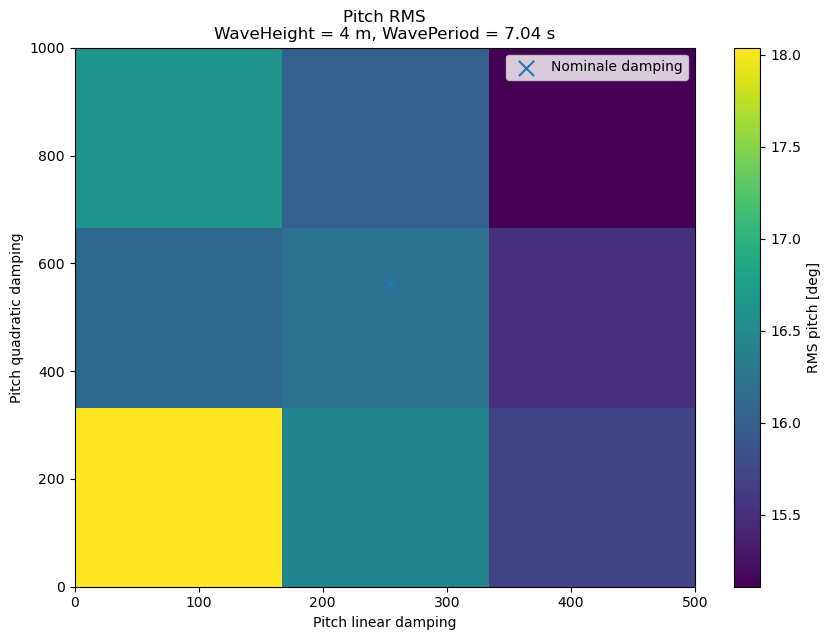

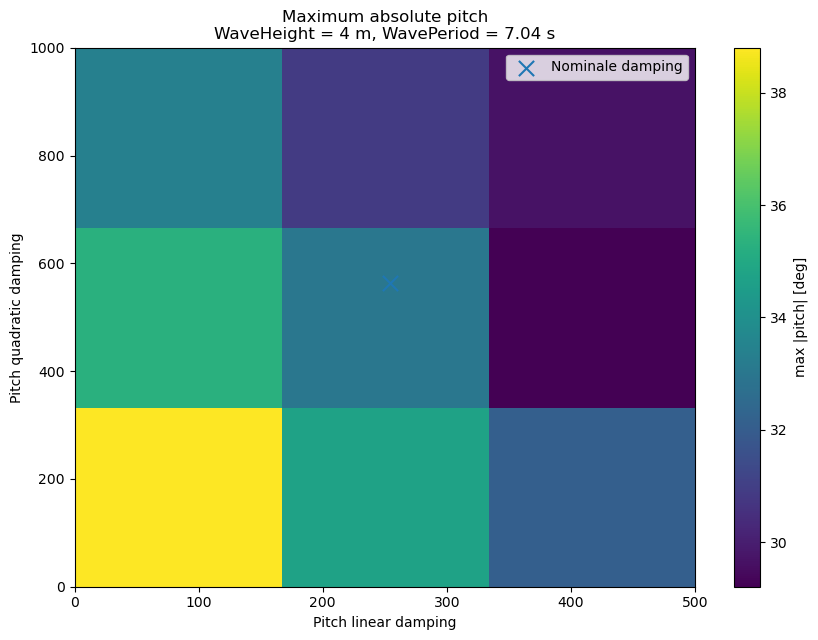

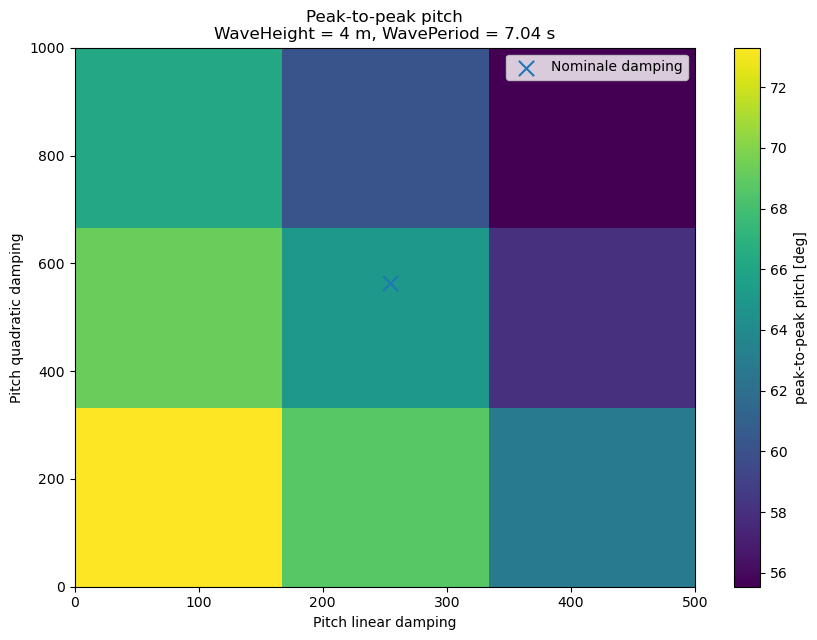

In [28]:
# ============================================================
# 6. Heatmaps van pitch response metrics
# ============================================================

def plot_heatmap(metric_col, title, cbar_label):
    pivot = results_df.pivot(index="quad", columns="lin", values=metric_col)

    plt.figure(figsize=(10, 7))
    im = plt.imshow(
        pivot.values,
        origin="lower",
        aspect="auto",
        extent=[
            pivot.columns.min(),
            pivot.columns.max(),
            pivot.index.min(),
            pivot.index.max(),
        ],
    )
    plt.colorbar(im, label=cbar_label)

    plt.scatter(
        [nominal_pitch_lin],
        [nominal_pitch_quad],
        marker="x",
        s=120,
        label="Nominale damping",
    )

    plt.xlabel("Pitch linear damping")
    plt.ylabel("Pitch quadratic damping")
    plt.title(f"{title}\nWaveHeight = {wave_height:g} m, WavePeriod = {wave_period:g} s")
    plt.legend()
    plt.grid(False)
    plt.show()

plot_heatmap("pitch_rms_deg", "Pitch RMS", "RMS pitch [deg]")
plot_heatmap("pitch_max_abs_deg", "Maximum absolute pitch", "max |pitch| [deg]")
plot_heatmap("pitch_ptp_deg", "Peak-to-peak pitch", "peak-to-peak pitch [deg]")


C:\Users\verav\AppData\Local\Temp\ipykernel_31100\3744143863.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


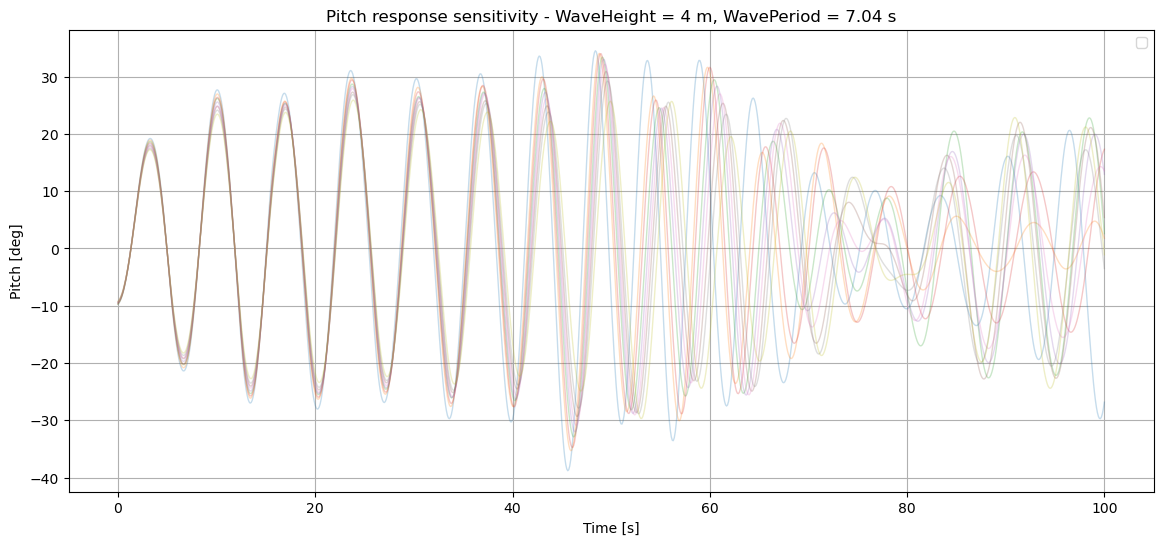

In [29]:
# ============================================================
# 7. Overlay: alle pitch tijdseries
# ============================================================

plt.figure(figsize=(14, 6))

for (lin, quad), data in time_histories.items():
    t = data["t"]
    pitch = data["pitch"]
    mask = t >= plot_start_time

    alpha = 0.25
    linewidth = 1.0

    # Nominale combinatie iets dikker tonen als die exact in het grid zit
    if np.isclose(lin, nominal_pitch_lin) and np.isclose(quad, nominal_pitch_quad):
        alpha = 1.0
        linewidth = 2.5

    plt.plot(
        t[mask],
        pitch[mask],
        alpha=alpha,
        linewidth=linewidth,
        label=f"lin={lin:.1f}, quad={quad:.1f}" if alpha == 1.0 else None,
    )

plt.xlabel("Time [s]")
plt.ylabel("Pitch [deg]")
plt.title(f"Pitch response sensitivity - WaveHeight = {wave_height:g} m, WavePeriod = {wave_period:g} s")
plt.grid(True)
plt.legend()
plt.show()


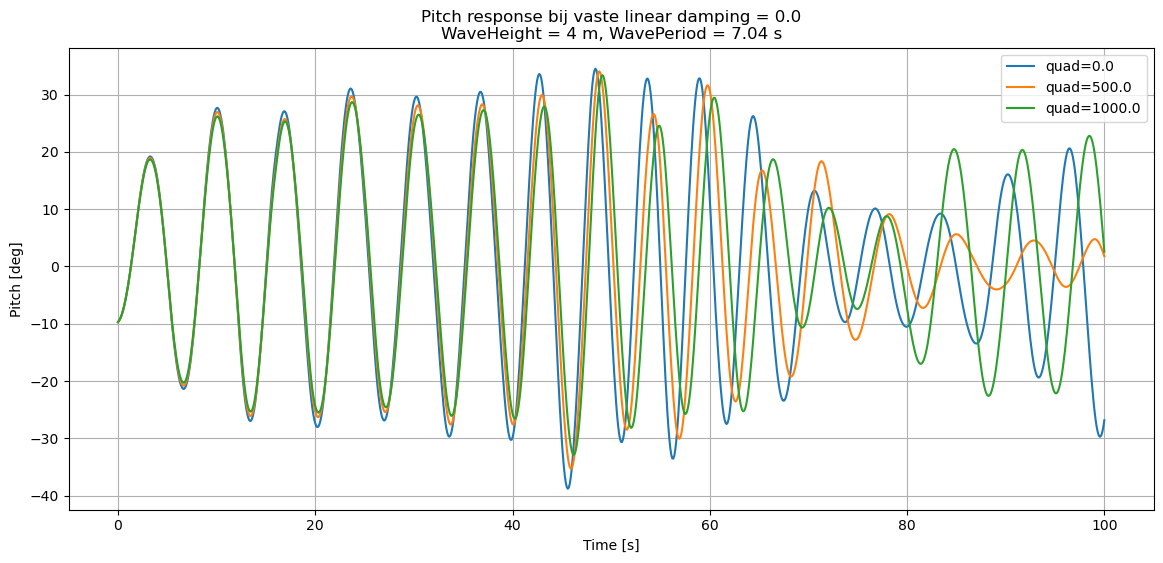

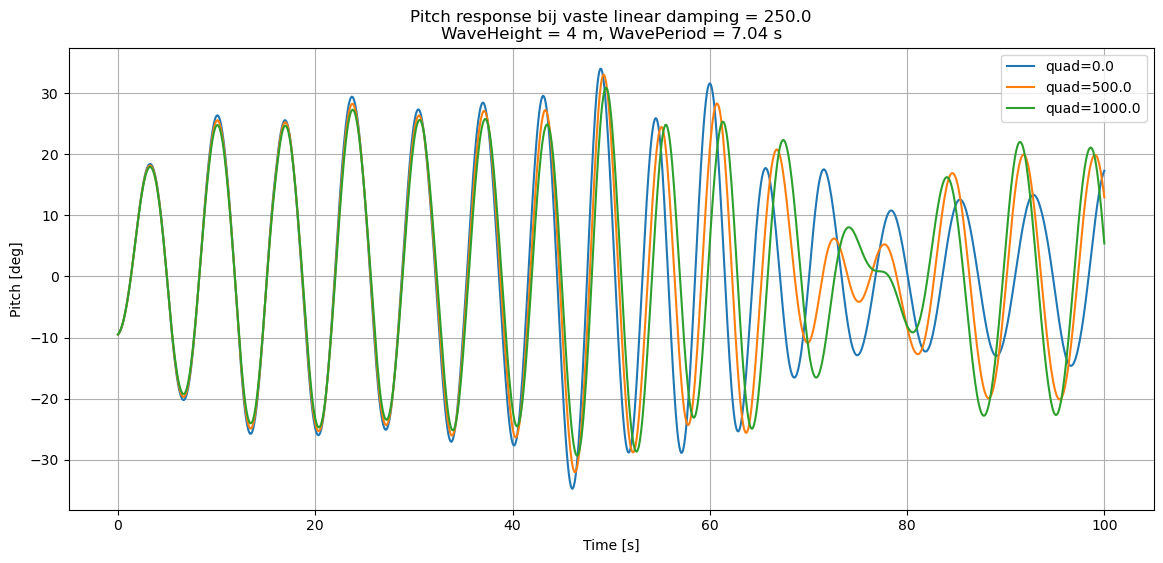

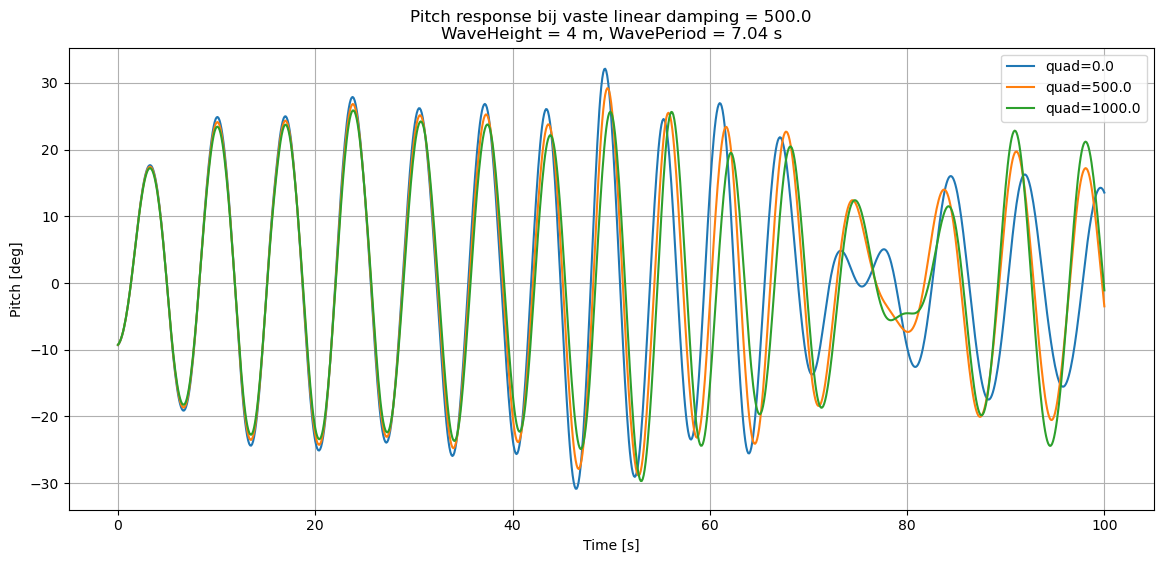

In [30]:
# ============================================================
# 8. Overlay per lineaire damping: effect van quadratic damping
# ============================================================

for lin in lin_values:
    plt.figure(figsize=(14, 6))

    for quad in quad_values:
        key = (float(lin), float(quad))
        if key not in time_histories:
            continue

        t = time_histories[key]["t"]
        pitch = time_histories[key]["pitch"]
        mask = t >= plot_start_time

        plt.plot(t[mask], pitch[mask], label=f"quad={quad:.1f}")

    plt.xlabel("Time [s]")
    plt.ylabel("Pitch [deg]")
    plt.title(
        f"Pitch response bij vaste linear damping = {lin:.1f}\n"
        f"WaveHeight = {wave_height:g} m, WavePeriod = {wave_period:g} s"
    )
    plt.grid(True)
    plt.legend()
    plt.show()


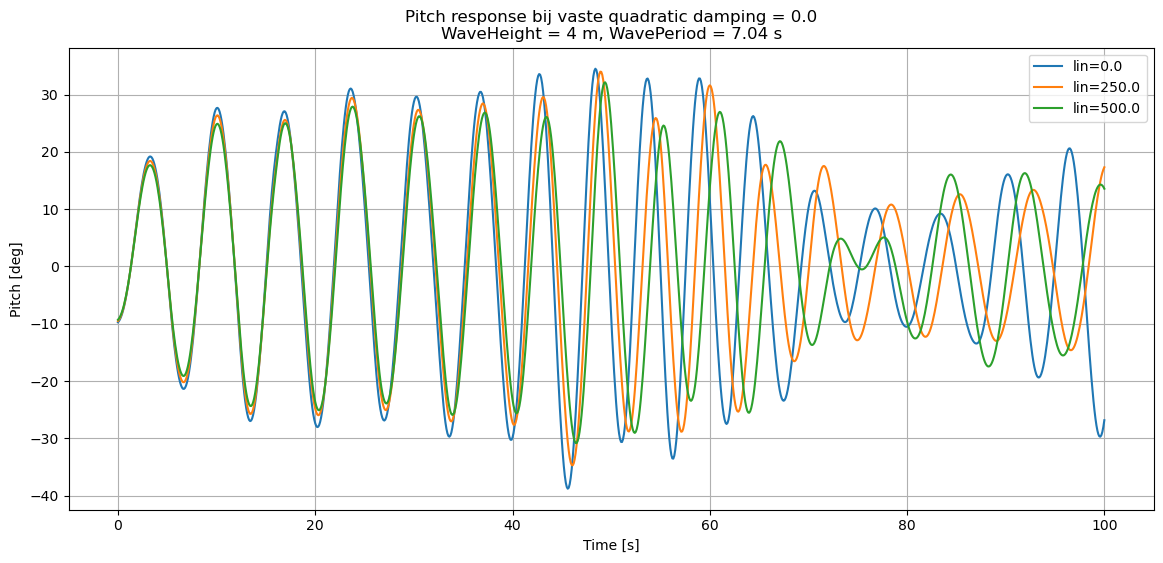

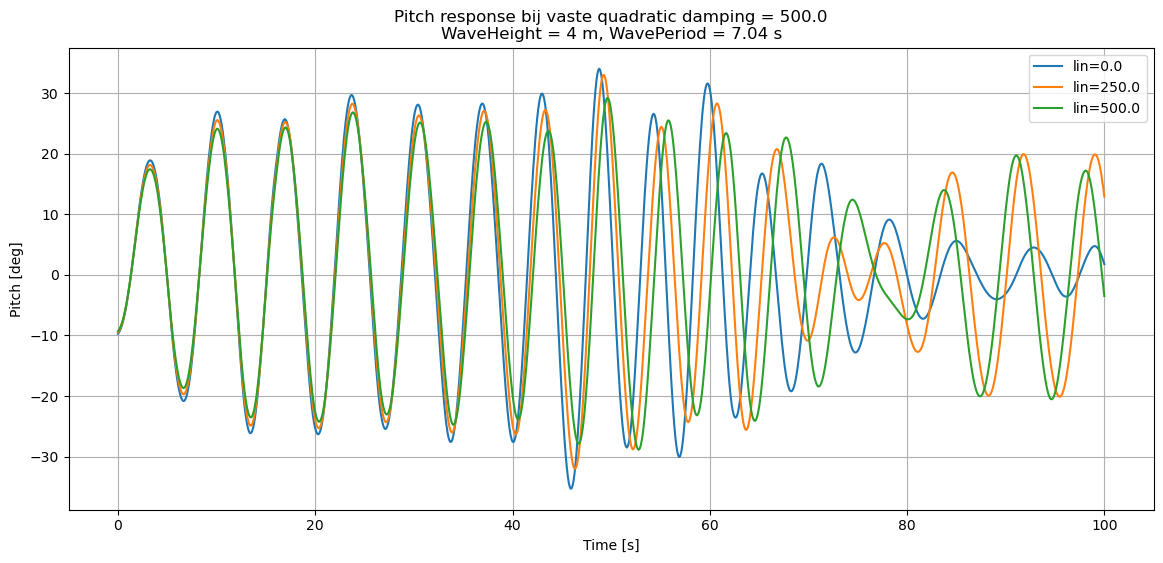

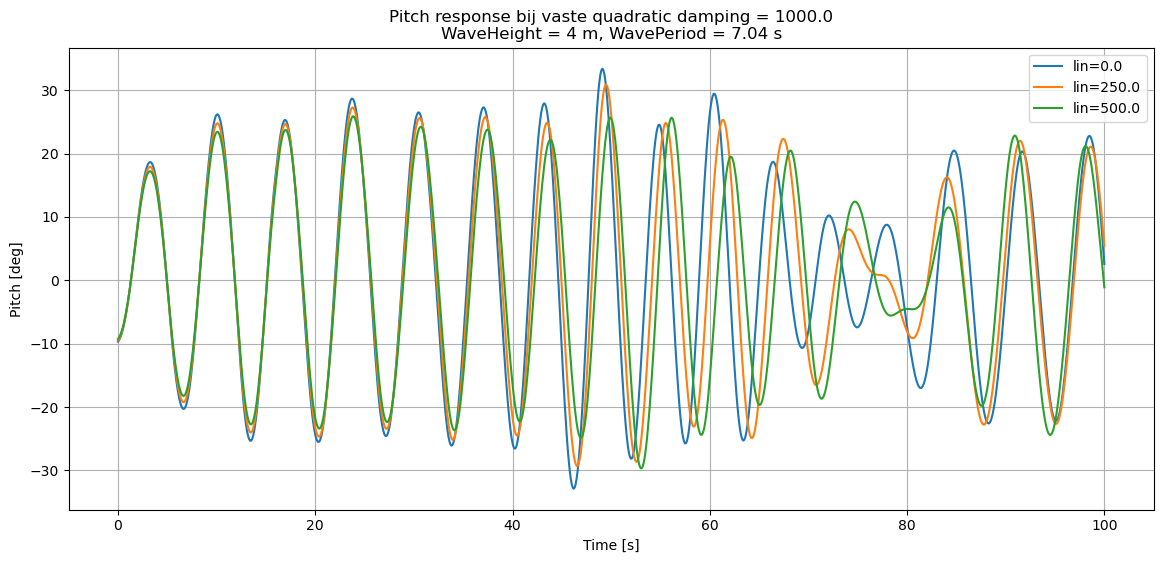

In [31]:
# ============================================================
# 9. Overlay per kwadratische damping: effect van linear damping
# ============================================================

for quad in quad_values:
    plt.figure(figsize=(14, 6))

    for lin in lin_values:
        key = (float(lin), float(quad))
        if key not in time_histories:
            continue

        t = time_histories[key]["t"]
        pitch = time_histories[key]["pitch"]
        mask = t >= plot_start_time

        plt.plot(t[mask], pitch[mask], label=f"lin={lin:.1f}")

    plt.xlabel("Time [s]")
    plt.ylabel("Pitch [deg]")
    plt.title(
        f"Pitch response bij vaste quadratic damping = {quad:.1f}\n"
        f"WaveHeight = {wave_height:g} m, WavePeriod = {wave_period:g} s"
    )
    plt.grid(True)
    plt.legend()
    plt.show()


In [32]:
# ============================================================
# 10. Tabel sorteren: laagste en hoogste pitch RMS
# ============================================================

ok = results_df[results_df["status"] == "ok"].copy()

print("Laagste pitch RMS:")
display(ok.sort_values("pitch_rms_deg").head(10))

print("Hoogste pitch RMS:")
display(ok.sort_values("pitch_rms_deg", ascending=False).head(10))


Laagste pitch RMS:


,lin,quad,status,pitch_mean_deg,pitch_std_deg,pitch_rms_deg,pitch_max_abs_deg,pitch_ptp_deg
8,500.0,1000.0,ok,0.302952,15.105722,15.108760,29.672343,55.537959
7,500.0,500.0,ok,0.463118,15.511687,15.518599,29.203806,58.069777
6,500.0,0.0,ok,0.469746,15.704656,15.711680,32.124565,62.956043
5,250.0,1000.0,ok,0.540312,15.994551,16.003674,30.878985,60.175664
1,0.0,500.0,ok,0.549644,16.084570,16.093959,35.305644,69.345941
4,250.0,500.0,ok,0.610216,16.189108,16.200604,32.992293,65.007896
3,250.0,0.0,ok,0.504316,16.422227,16.429968,34.726850,68.714988
2,0.0,1000.0,ok,0.696193,16.619942,16.634517,33.387170,66.285405
0,0.0,0.0,ok,0.067474,18.038290,18.038416,38.801109,73.301375


Hoogste pitch RMS:


,lin,quad,status,pitch_mean_deg,pitch_std_deg,pitch_rms_deg,pitch_max_abs_deg,pitch_ptp_deg
0,0.0,0.0,ok,0.067474,18.038290,18.038416,38.801109,73.301375
2,0.0,1000.0,ok,0.696193,16.619942,16.634517,33.387170,66.285405
3,250.0,0.0,ok,0.504316,16.422227,16.429968,34.726850,68.714988
4,250.0,500.0,ok,0.610216,16.189108,16.200604,32.992293,65.007896
1,0.0,500.0,ok,0.549644,16.084570,16.093959,35.305644,69.345941
5,250.0,1000.0,ok,0.540312,15.994551,16.003674,30.878985,60.175664
6,500.0,0.0,ok,0.469746,15.704656,15.711680,32.124565,62.956043
7,500.0,500.0,ok,0.463118,15.511687,15.518599,29.203806,58.069777
8,500.0,1000.0,ok,0.302952,15.105722,15.108760,29.672343,55.537959
